In [22]:
import pandas as pd
df = pd.read_csv('student.csv')
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9
395,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6


In [21]:
df.isnull()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
393,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
394,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
395,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [23]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [24]:
# Calculate mean of numerical columns
mean_values = df.mean(numeric_only=True)

print(mean_values)

age           16.705290
Medu           2.748111
Fedu           2.521411
traveltime     1.450882
studytime      2.032746
failures       0.335013
famrel         3.944584
freetime       3.234257
goout          3.108312
Dalc           1.478589
Walc           2.289673
health         3.556675
absences       5.695214
G1            10.881612
G2            10.687657
G3            10.377834
dtype: float64


In [25]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [26]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [27]:
df.drop_duplicates(inplace=True)

In [28]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [29]:
Q1 = df['G3'].quantile(0.25)
Q3 = df['G3'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['G3'] < Q1 - 1.5*IQR) | (df['G3'] > Q3 + 1.5*IQR)]

print(outliers)

Empty DataFrame
Columns: [school, sex, age, address, famsize, Pstatus, Medu, Fedu, Mjob, Fjob, reason, guardian, traveltime, studytime, failures, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic, famrel, freetime, goout, Dalc, Walc, health, absences, G1, G2, G3]
Index: []

[0 rows x 33 columns]


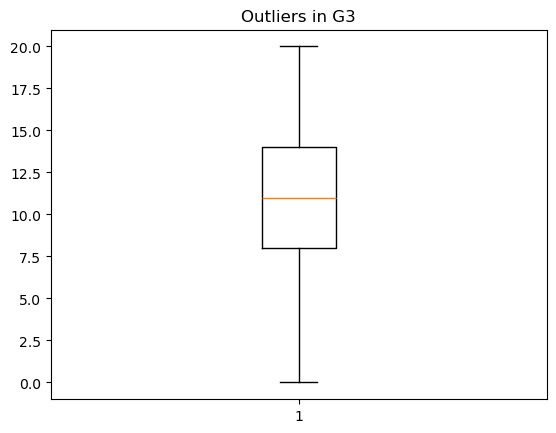

In [30]:
import matplotlib.pyplot as plt

plt.boxplot(df['G3'])
plt.title("Outliers in G3")
plt.show()

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['G3']] = scaler.fit_transform(df[['G3']])

print(df[['G3']])

       G3
0    0.30
1    0.30
2    0.50
3    0.75
4    0.50
..    ...
390  0.45
391  0.80
392  0.35
393  0.50
394  0.45

[395 rows x 1 columns]


In [32]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['school'] = encoder.fit_transform(df['school'])

print(df[['school']])

     school
0         0
1         0
2         0
3         0
4         0
..      ...
390       1
391       1
392       1
393       1
394       1

[395 rows x 1 columns]


In [33]:
categorical = ['sex','address','famsize','Pstatus','Mjob','Fjob']

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

In [34]:
df = pd.get_dummies(df, columns=['school','sex','address'], drop_first=True)

In [35]:
print(df.describe())

              age     famsize     Pstatus        Medu        Fedu        Mjob  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    0.288608    0.896203    2.749367    2.521519    2.169620   
std      1.276043    0.453690    0.305384    1.094735    1.088201    1.227473   
min     15.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%     16.000000    0.000000    1.000000    2.000000    2.000000    2.000000   
50%     17.000000    0.000000    1.000000    3.000000    2.000000    2.000000   
75%     18.000000    1.000000    1.000000    4.000000    3.000000    3.000000   
max     22.000000    1.000000    1.000000    4.000000    4.000000    4.000000   

             Fjob  traveltime   studytime    failures      famrel    freetime  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     2.281013    1.448101    2.035443    0.334177    3.944304    3.235443   
std      0.863542    0.6975